# Structural analysis.

In [1]:
import numpy as np
import matplotlib        as mpl
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("ticks")

mpl.rcParams['font.family'] = ['serif']
mpl.rcParams['mathtext.fontset'] = 'dejavuserif'
mpl.rcParams['font.size'] = 8.

cm = 1/2.54  # centimeters in inches
colors = ["#F9D9D8", "#EDA3B2", "#7E73AC"]

In [2]:
def get_projected_angle() -> tuple[np.ndarray, np.ndarray]:
  with open('./zpdbs/struct_adk/adk_angles.txt', 'r') as f:
    lines = f.readlines()[1:]
    words = [l.split() for l in lines]
    nmp = np.asarray([float(_[1]) for _ in words])
    lid = np.asarray([float(_[2]) for _ in words])
  return nmp, lid

def get_projected_dist() -> np.ndarray:
  with open('./zpdbs/struct_adk/adk_dist.txt', 'r') as f:
    lines = f.readlines()[1:]
    words = [l.split() for l in lines]
    dists = np.asarray([float(_[1]) for _ in words])
  return dists

nmp_core, lid_core = get_projected_angle()
nmp_lid = get_projected_dist()
print(nmp_core.max(), nmp_core.min(), lid_core.max(), lid_core.min())

72.441 36.482 175.357 101.523


6.25 4.75
36.482 72.441 101.523 175.357


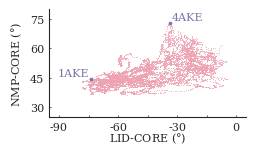

In [3]:
figspec= {'lmargin': 1  *cm, 
          'rmargin': 1/4*cm,
          'hgap':    1/4*cm,
          'hsize':  20/4*cm,
          'bmargin': 1  *cm,
          'tmargin': 1  *cm,
          'vgap':    1  *cm,
          'vsize':  11/4*cm,}

figsize = (figspec['lmargin'] + figspec['hsize'] + (figspec['hgap']+figspec['hsize'])*0 + figspec['rmargin'], 
           figspec['bmargin'] + figspec['vsize'] + (figspec['vgap']+figspec['vsize'])*0 + figspec['tmargin'], )
print(figsize[0]/cm, figsize[1]/cm)
print(nmp_core.min(), nmp_core.max(), lid_core.min(), lid_core.max())

fig, axes = plt.subplots(1, 1, figsize=figsize, sharey=True, 
    gridspec_kw=dict(left  =figspec['lmargin']/figsize[0], right=1.-figspec['rmargin']/figsize[0],
                     bottom=figspec['bmargin']/figsize[1], top  =1.-figspec['tmargin']/figsize[1],
                     wspace=figspec['hgap']/figspec['hsize'],
                     hspace=figspec['vgap']/figspec['vsize'], ))
axes.scatter(lid_core, nmp_core, s=.3, c=colors[1], lw=0.)
axes.scatter((106.075, 146.544), (44.314, 73.006), s=7, c=colors[2], lw=0.)
axes.text(105.5, 47.3, r'1AKE', color=colors[2], ha='right', va='center')
axes.text(147. , 76.1, r'4AKE', color=colors[2], ha='left',  va='center')
axes.set(ylim=(25, 80), 
         yticks=(30, 45, 60, 75), 
         xlim=(85, 185), 
         xticks=(90, 105, 120, 135, 150, 165, 180), 
         xticklabels=(-90, '', -60, '', -30, '', 0), )
axes.set_ylabel(r'NMP-CORE ($\degree$)', fontsize=8, ha='center')
axes.set_xlabel(r'LID-CORE ($\degree$)', fontsize=8, va='center')

axes.minorticks_off()
axes.spines[['top','right']].set_visible(False)
axes.tick_params(direction='in', width=.5, length=1.5, axis='both', labelsize=8)
plt.savefig(f'./zfigures/fig_struct_adk_angle.jpg', dpi=300)

15.0 4.0
open 175
closed 729
open 2823
closed 3064
open 4273
closed 5558
open 6191
closed 6496
open 7042
closed 8196
open 8563
closed 8902
open 9999


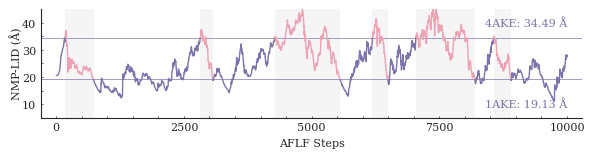

In [8]:
figspec= {'lmargin': 1  *cm, 
          'rmargin': 1/4*cm,
          'hgap':    1/4*cm,
          'hsize':   55/4*cm,
          'bmargin': 1  *cm,
          'tmargin': 1/4*cm,
          'vgap':    1  *cm,
          'vsize':   11/4*cm,}

figsize = (figspec['lmargin'] + figspec['hsize'] + (figspec['hgap']+figspec['hsize'])*0 + figspec['rmargin'], 
           figspec['bmargin'] + figspec['vsize'] + (figspec['vgap']+figspec['vsize'])*0 + figspec['tmargin'], )
print(figsize[0]/cm, figsize[1]/cm)

fig, axes = plt.subplots(1, 1, figsize=figsize, sharey=True, 
    gridspec_kw=dict(left  =figspec['lmargin']/figsize[0], right=1.-figspec['rmargin']/figsize[0],
                     bottom=figspec['bmargin']/figsize[1], top  =1.-figspec['tmargin']/figsize[1],
                     wspace=figspec['hgap']/figspec['hsize'],
                     hspace=figspec['vgap']/figspec['vsize'], ))
# plot by transitions.
to_closed = np.argwhere(nmp_lid<=19.13)
to_open   = np.argwhere(nmp_lid>=34.49)
start_step = 0
switch_closed = True
segments = []
for i_step in np.arange(nmp_lid.shape[0]):
  if switch_closed==True  and i_step in to_open   or i_step==nmp_lid.shape[0]-1:
    print('open', i_step)
    axes.plot(np.arange(start_step, i_step+1), nmp_lid[start_step:i_step+1], ls='-', lw=1., c=colors[2])
    switch_closed = False; start_step = i_step; continue
  if switch_closed==False and i_step in to_closed or i_step==nmp_lid.shape[0]-1:
    print('closed', i_step)
    axes.plot(np.arange(start_step, i_step+1), nmp_lid[start_step:i_step+1], ls='-', lw=1., c=colors[1])
    if i_step!=nmp_lid.shape[0]-1 and start_step!=0:
      axes.axvspan(start_step, i_step+1, color='#E6E6E6', alpha=0.4, zorder=0, lw=0)
    switch_closed = True; start_step = i_step; continue
axes.axhline(y=19.13, color=colors[2], ls='-', lw=0.5, zorder=0)
axes.axhline(y=34.49, color=colors[2], ls='-', lw=0.5, zorder=0)
axes.text(10000., 10., r'1AKE: 19.13 Å', color=colors[2], ha='right', va='center')
axes.text(10000., 40., r'4AKE: 34.49 Å', color=colors[2], ha='right', va='center')
axes.set(ylim=(5, 45), 
         yticks=(10, 15, 20, 25, 30, 35, 40),
         yticklabels=(10, '', 20, '', 30, '', 40),
         xlim=(-300, 10300), 
         xticks=(   0,  500, 1000, 1500, 2000, 
                 2500, 3000, 3500, 4000, 4500, 
                 5000, 5500, 6000, 6500, 7000, 
                 7500, 8000, 8500, 9000, 9500, 10000), 
         xticklabels=(   0, '', '', '', '', 
                      2500, '', '', '', '', 
                      5000, '', '', '', '', 
                      7500, '', '', '', '', 10000), )
axes.set_ylabel(r'NMP-LID (Å)', fontsize=8, va='center')
axes.set_xlabel(r'AFLF Steps', fontsize=8, ha='center')

axes.minorticks_off()
axes.spines[['top','right']].set_visible(False)
axes.tick_params(direction='in', width=.5, length=1.5, axis='both', labelsize=8)
plt.savefig(f'./zfigures/fig_struct_adk_dist.jpg', dpi=300)